In [ ]:
# import warnings
# from cryptography.utils import CryptographyDeprecationWarning
# warnings.filterwarnings("ignore", category=CryptographyDeprecationWarning)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
import scipy.io.wavfile as wf
import librosa
import lightgbm
%matplotlib inline
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

In [2]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']

In [3]:
train_df.isnull().sum()

Id                                       0
path                                     0
speakerId                                0
action                                   0
object                                   0
Self-reported fluency level              0
First Language spoken                    0
Current language used for work/school    0
gender                                   0
ageRange                                 0
dtype: int64

In [4]:
train_df[train_df.eq('none')].count()

Id                                          0
path                                        0
speakerId                                   0
action                                      0
object                                   1113
Self-reported fluency level                 0
First Language spoken                       0
Current language used for work/school       0
gender                                      0
ageRange                                    0
dtype: int64

In [5]:
train_df[train_df['object'] == 'none']['action']

0       change language
47      change language
48      change language
49      change language
50      change language
             ...       
9815    change language
9816    change language
9817    change language
9845    change language
9847    change language
Name: action, Length: 1113, dtype: object

In [6]:
train_df.duplicated().sum()

0

In [7]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

train_df

,Id,path,speakerId,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange,intention
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,change languagenone
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,activatemusic
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,deactivatelights
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
...,...,...,...,...,...,...,...,...,...
9849,9849,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,decreasevolume
9850,9850,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9851,9851,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9852,9852,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights


In [8]:
train_df['intention'].value_counts()

intention
increasevolume         2614
decreasevolume         2386
increaseheat           1209
decreaseheat           1189
change languagenone    1113
activatemusic           791
deactivatelights        552
Name: count, dtype: int64

In [9]:
train_df['speakerId'].nunique()

87

In [10]:
train_df.drop(['Id' , 'speakerId'], axis=1, inplace=True)

In [11]:
train_df['Self-reported fluency level '].value_counts() / len(train_df)

Self-reported fluency level 
native          0.958393
advanced        0.035113
basic           0.005683
intermediate    0.000812
Name: count, dtype: float64

In [12]:
train_df['First Language spoken'].value_counts() / len(train_df)

First Language spoken
English (United States)    0.978486
French (Canada)            0.015019
Spanish (Venezuela)        0.003552
Telugu                     0.002131
English (Canada)           0.000812
Name: count, dtype: float64

In [13]:
train_df['Current language used for work/school'].value_counts() / len(train_df)

Current language used for work/school
English (United States)    0.974021
English (Canada)           0.015831
English (Australia)        0.006596
Spanish (Venezuela)        0.003552
Name: count, dtype: float64

In [14]:
train_df.drop(['Self-reported fluency level ', 'First Language spoken', 'Current language used for work/school'], axis=1, inplace=True)

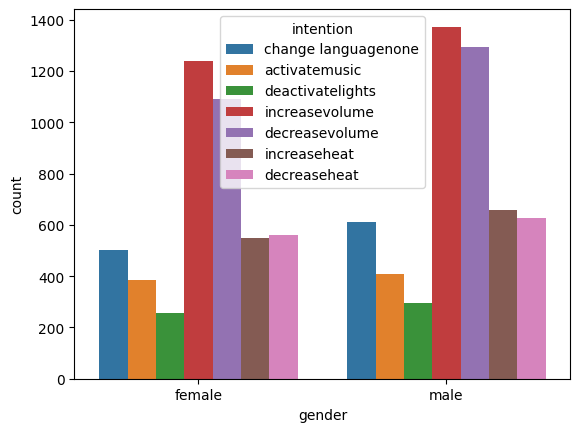

In [15]:
train_df['intention'] = train_df['intention'].str.strip()

sns.countplot(data=train_df, x='gender', hue='intention')
plt.show()

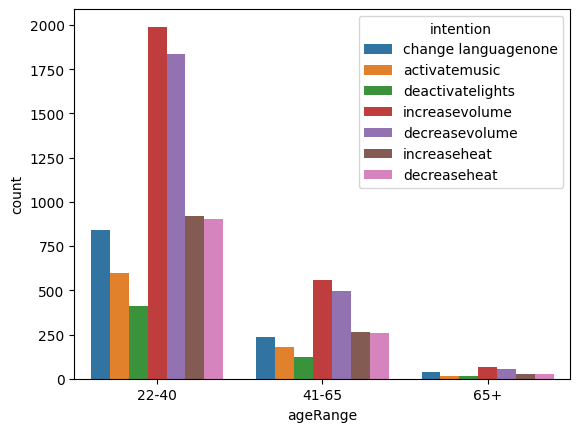

In [16]:
sns.countplot(data=train_df, x='ageRange', hue='intention')
plt.show()

In [17]:
train_df.drop(['gender', 'ageRange'], axis=1, inplace=True)

In [19]:
def get_audio_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Failed on {file_path}: {e}")
        return None

train_df["duration"] = train_df["path"].apply(get_audio_duration)

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [20]:
train_df

,path,intention,duration
0,D:/Data Science and Engineering/Datasets/dsl_d...,change languagenone,1.857625
1,D:/Data Science and Engineering/Datasets/dsl_d...,activatemusic,1.393188
2,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights,1.950500
3,D:/Data Science and Engineering/Datasets/dsl_d...,increasevolume,1.764687
4,D:/Data Science and Engineering/Datasets/dsl_d...,increasevolume,2.414875
...,...,...,...
9849,D:/Data Science and Engineering/Datasets/dsl_d...,decreasevolume,2.730688
9850,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights,2.645313
9851,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights,2.645313
9852,D:/Data Science and Engineering/Datasets/dsl_d...,deactivatelights,2.304000


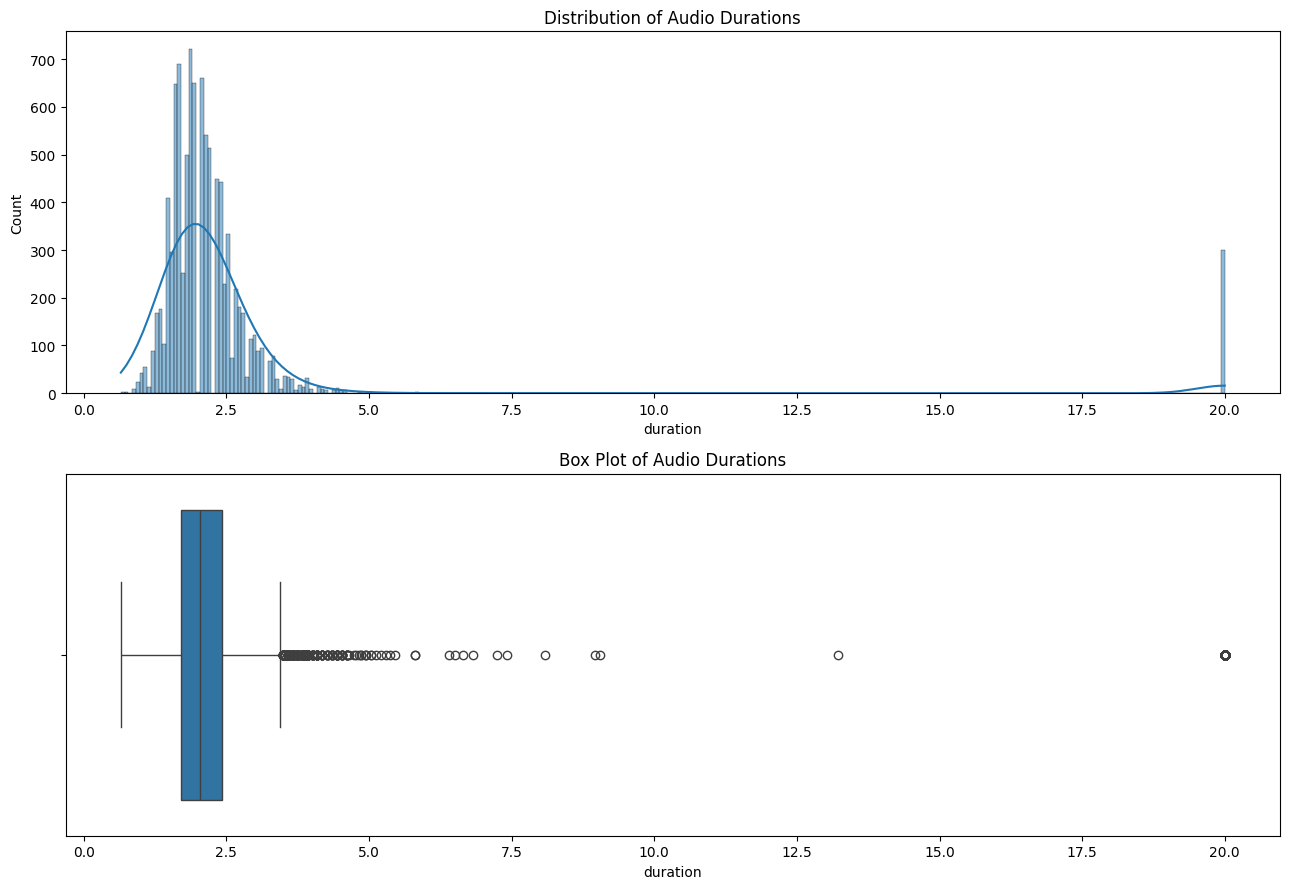

In [21]:
fig, axes = plt.subplots(nrows=2, figsize=(13, 9))

# Histogram
hist_plot = sns.histplot(train_df['duration'], ax=axes[0], kde=True)  # kde=True adds a density curve

# Box plot
box_plot = sns.boxplot(x=train_df['duration'], ax=axes[1])

axes[0].set_title('Distribution of Audio Durations')
axes[1].set_title('Box Plot of Audio Durations')

plt.tight_layout()
plt.show()

In [22]:
z_score = np.abs(stats.zscore(train_df['duration']))

np.where(z_score>3)

(array([  36,   55,  108,  121,  130,  134,  184,  200,  263,  332,  335,
         341,  380,  471,  484,  493,  539,  568,  616,  628,  650,  746,
         831,  844,  853,  939, 1144, 1174, 1230, 1288, 1374, 1392, 1481,
        1506, 1509, 1555, 1574, 1597, 1616, 1639, 1643, 1753, 1852, 1854,
        1936, 1981, 1993, 2008, 2011, 2096, 2123, 2131, 2189, 2232, 2253,
        2262, 2306, 2334, 2419, 2556, 2593, 2597, 2738, 2765, 2777, 2826,
        2835, 2879, 2888, 2933, 2940, 2958, 2985, 3008, 3066, 3067, 3081,
        3093, 3109, 3112, 3187, 3190, 3219, 3322, 3331, 3350, 3396, 3480,
        3592, 3597, 3609, 3657, 3784, 3823, 3827, 3896, 3952, 4000, 4047,
        4089, 4125, 4173, 4183, 4261, 4394, 4433, 4460, 4521, 4524, 4531,
        4690, 4699, 4715, 4723, 4768, 4853, 4866, 4985, 5038, 5108, 5136,
        5167, 5225, 5238, 5240, 5244, 5246, 5285, 5292, 5321, 5326, 5452,
        5476, 5497, 5574, 5580, 5595, 5636, 5859, 5866, 5881, 5906, 5930,
        5956, 5983, 6047, 6050, 6264, 

In [23]:
print(train_df.shape)

clean_df = train_df[z_score<3]
clean_df.shape

(9854, 3)


(9553, 3)

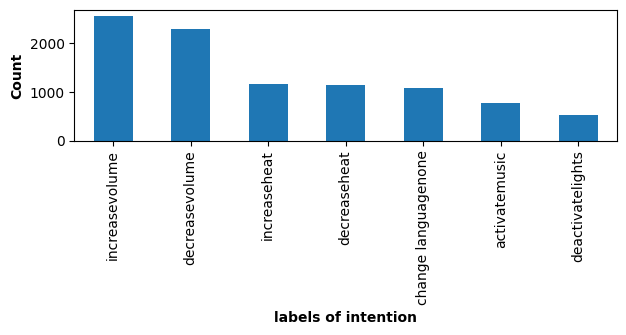

intention
increasevolume         2553
decreasevolume         2299
increaseheat           1173
decreaseheat           1148
change languagenone    1078
activatemusic           765
deactivatelights        537
Name: count, dtype: int64

In [24]:
ax = clean_df['intention'].value_counts().plot(kind='bar', colormap = 'tab10', figsize=(7,1.7))
plt.xlabel("labels of intention",fontweight = 'bold')
plt.ylabel("Count",fontweight = 'bold')
plt.show()

clean_df['intention'].value_counts()

In [25]:
clean_df.loc[:, 'intention'] = clean_df['intention'].replace('change languagenone', 'changelanguage')

In [26]:
audiopath = clean_df['path'].tolist()

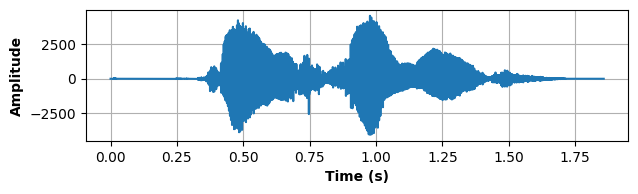

In [27]:
wavfile= audiopath[0]
a, b= wf.read(wavfile)

duration= len(b)/a 
c= np.linspace(0,duration,len(b))
plt.figure(figsize=(7,1.7))
plt.plot(c,b)
plt.grid()
plt.xlabel('Time (s)', fontweight = 'bold')
plt.ylabel('Amplitude', fontweight = 'bold')
plt.show()

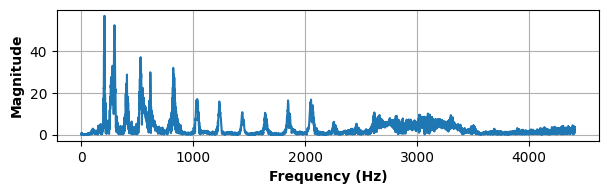

In [28]:
k,sr= librosa.load(audiopath[0])

a = np.fft.fft(k)
a_mag = np.absolute(a)
plt.figure(figsize=(7,1.7))
b = np.linspace(0, sr, len(a_mag))
b_bins = int(len(a_mag)*0.2)  
plt.plot(b[:b_bins], a_mag[:b_bins])
plt.ylabel('Magnitude', fontweight = 'bold')
plt.xlabel('Frequency (Hz)', fontweight = 'bold')
plt.grid()
plt.show()

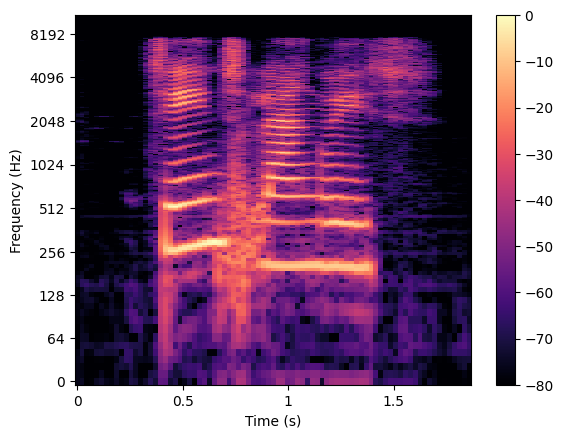

<Figure size 500x400 with 0 Axes>

In [29]:
k, sr= librosa.load(audiopath[0])
a= librosa.stft(k)
b= librosa.amplitude_to_db(np.abs(a), ref=np.max)

fig, ax= plt.subplots()
pic= librosa.display.specshow(b, x_axis='time', y_axis='log', ax=ax)
ax.set(ylabel='Frequency (Hz)', xlabel='Time (s)')
fig.colorbar(pic, ax=ax)
plt.figure(figsize=(5,4))
plt.show()

In [30]:
DBT = []
mfccs = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=processed_audio, sr=sr)

    DBT.append(duration_before_trim)
    mfccs.append(mfcc)

Processing Audio: 100%|██████████| 9553/9553 [02:27<00:00, 64.74it/s]


In [31]:
feature= np.array(mfccs)
feature= feature.reshape(feature.shape[0], -1)

In [32]:
x= feature
y= clean_df['intention']

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=4, stratify=y)

In [34]:
scaler_minmax = MinMaxScaler()

x_train_scaled = scaler_minmax.fit_transform(x_train)
x_test_scaled = scaler_minmax.transform(x_test)

In [35]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [36]:
pca = PCA(n_components=500, random_state=4)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Classification Models

In [ ]:
svc = SVC(kernel='rbf', C=40, gamma='scale',class_weight='balanced' , random_state=4)
svc.fit(x_train_pca, y_train_encoded)

y_pred_svc = svc.predict(x_test_pca)
svc_acc = accuracy_score(y_test_encoded, y_pred_svc) * 100
f1_svc = f1_score(y_test_encoded, y_pred_svc, average='weighted') * 100

print(f"Accuracy Score: {svc_acc:.4f}")
print(f"F1 Score: {f1_svc:.4f}")

In [ ]:
LGBM= lightgbm.LGBMClassifier(random_state=4, n_estimators=2000, num_leaves=70, learning_rate=0.05, class_weight='balanced', importance_type='gain', force_col_wise=True)
LGBM.fit(x_train_scaled, y_train_encoded)

y_pred_lgbm = LGBM.predict(x_test_scaled)
lgbm_acc = accuracy_score(y_test_encoded, y_pred_lgbm) * 100
f1_lgbm = f1_score(y_test_encoded, y_pred_lgbm, average='weighted') * 100
lgbm_rec = recall_score(y_test_encoded, y_pred_lgbm, average='micro') * 100

print(f"Accuracy Score: {lgbm_acc:.4f}")
print(f"F1 Score: {f1_lgbm:.4f}")
print(f"Recall Score: {lgbm_rec:.4f}")

[LightGBM] [Info] Total Bins 468449
[LightGBM] [Info] Number of data points in the train set: 7642, number of used features: 2416
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [47]:
df = pd.DataFrame({'models': ['SVM', 'lightGBM'], 'Acuracy': [svc_acc, lgbm_acc], 'f1_score': [f1_svc, f1_gbm]})
df

,models,Acuracy,f1_score
0,SVM,76.452119,76.291552
1,lightGBM,72.579801,72.398585
